#### 데이터 로드

In [1]:
# 데이터 확인
import pandas as pd

df = pd.read_csv('news_preprocessed_2025.csv')
df.head()

,title,content,date,press,url,text,clean_text,tokens
0,경기 침체에 금리 인하 가능성…하반기 대출 규제 더 세진다,[2025 금융시장 대전망] <1>깐깐해지는 가계빚 관리 가계대출 증가 한도 70조...,2025-01-02 17:56:27,서울경제,https://n.news.naver.com/mnews/article/011/000...,경기 침체에 금리 인하 가능성…하반기 대출 규제 더 세진다 [2025 금융시장 대전...,경기 침체에 금리 인하 가능성 하반기 대출 규제 더 세진다 금융시장 대전망 깐깐해지...,"['경기', '침체', '금리', '인하', '하반기', '대출', '규제', '금..."
1,중기부에 AI전담 TF생긴다,AI생산적용 中企 1.5%그쳐 제조현장 AI 활성화 돕고 스마트제조기업 육성 취지 ...,2025-01-02 17:58:11,매일경제,https://n.news.naver.com/mnews/article/009/000...,중기부에 AI전담 TF생긴다 AI생산적용 中企 1.5%그쳐 제조현장 AI 활성화 돕...,중기부에 전담 생긴다 생산적용 그쳐 제조현장 활성화 돕고 스마트제조기업 육성 취지 ...,"['중기', '전담', '생기', '생산', '적용', '그치', '제조', '현장..."
2,"현대차그룹 전기차 5종, 美서 전기차 보조금 받는다",현대차 아이오닉 9·기아 EV9 등 현지 EV 생산 본격화…IRA 수혜 '트럼프 2...,2025-01-02 17:58:14,이데일리,https://n.news.naver.com/mnews/article/018/000...,"현대차그룹 전기차 5종, 美서 전기차 보조금 받는다 현대차 아이오닉 9·기아 EV9...",현대차그룹 전기차 종 서 전기차 보조금 받는다 현대차 아이오닉 기아 등 현지 생산 ...,"['현대차그룹', '전기', '전기', '보조금', '현대차', '아이오닉', '기..."
3,"4대금융 ""견고한 신뢰 쌓아 위기 넘겠다""","주요 금융그룹, 비상경영 선언 회장들, 신년사서 일제히 ""위기"" 불확실성에 신뢰 구...",2025-01-02 17:58:21,한국경제,https://n.news.naver.com/mnews/article/015/000...,"4대금융 ""견고한 신뢰 쌓아 위기 넘겠다"" 주요 금융그룹, 비상경영 선언 회장들, ...",대금융 견고한 신뢰 쌓아 위기 넘겠다 주요 금융그룹 비상경영 선언 회장들 신년사서 ...,"['금융', '신뢰', '위기', '금융', '그룹', '비상', '경영', '선언..."
4,"김영록 전남지사, 여객기 사고 피해지원 특별법 제정 건의",(무안=연합뉴스) 형민우 기자 = 김영록 전남지사는 2일 무안국제공항 분향소를 찾은...,2025-01-02 17:58:54,연합뉴스,https://n.news.naver.com/mnews/article/001/001...,"김영록 전남지사, 여객기 사고 피해지원 특별법 제정 건의 (무안=연합뉴스) 형민우 ...",김영록 전남지사 여객기 사고 피해지원 특별법 제정 건의 무안 연합뉴스 형민우 기자 ...,"['김영록', '전남', '지사', '여객기', '사고', '피해', '특별법', ..."


In [2]:
# tokens를 실제 리스트 형식으로 변환
import ast

df["tokens"] = df["tokens"].apply(ast.literal_eval)

#### 1️⃣ Dictionary 생성 (단어 → ID)

In [3]:
from gensim.corpora import Dictionary

dictionary = Dictionary(df["tokens"])

# 너무 일반적인 단어 제거
dictionary.filter_extremes(no_below=5, no_above=0.5)

#### 2️⃣ Corpus 생성 (문서 → 단어 빈도 벡터)

In [4]:
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

#### 3️⃣ LDA 모델 학습

In [5]:
# 1. 최적의 토픽 개수 탐색
from gensim.models import LdaModel
from gensim.models import CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10):
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=10,
            random_state=42
        )
        
        model_list.append(model)
        
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        
        coherence_values.append(coherencemodel.get_coherence())
    
    return model_list, coherence_values


In [6]:
# 2. 실행
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=df["tokens"],
    start=2,
    limit=10
)


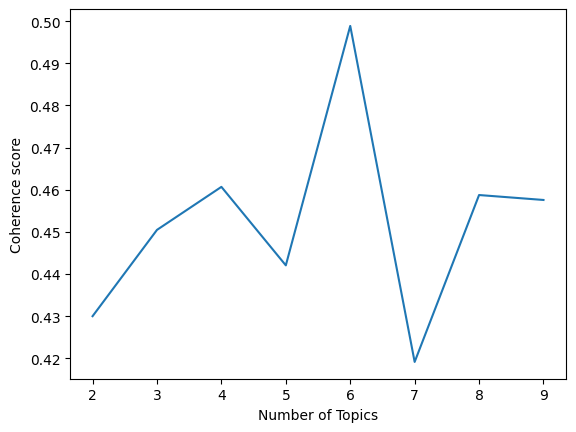

In [7]:
# 3. 시각화
import matplotlib.pyplot as plt

x = range(2,10)

plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.show()


In [8]:
# 4. 최적 토픽 개수 선택
best_index = coherence_values.index(max(coherence_values))
lda_model = model_list[best_index]

print("최적 토픽 개수:", best_index + 2)
print("Coherence score:", max(coherence_values))


최적 토픽 개수: 6
Coherence score: 0.4988807455445458


#### 4️⃣ 토픽 확인

In [9]:
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)

(0, '0.023*"공항" + 0.013*"안전" + 0.013*"사고" + 0.012*"항공" + 0.011*"제주" + 0.010*"공사" + 0.010*"콘크리트" + 0.009*"무안" + 0.008*"설계" + 0.008*"시설"')
(1, '0.023*"미국" + 0.018*"생산" + 0.018*"전기" + 0.015*"보조금" + 0.013*"회장" + 0.010*"공장" + 0.010*"성장" + 0.009*"현대차그룹" + 0.008*"가격" + 0.008*"최대"')
(2, '0.064*"금융" + 0.042*"센터" + 0.025*"센터장" + 0.015*"부장" + 0.012*"기업" + 0.010*"사업" + 0.010*"팀장" + 0.010*"전략" + 0.009*"분양" + 0.008*"은행"')
(3, '0.019*"사업" + 0.015*"혁신" + 0.011*"위기" + 0.011*"회장" + 0.010*"경영" + 0.010*"신년사" + 0.010*"기업" + 0.009*"기술" + 0.008*"그룹" + 0.008*"지역"')
(4, '0.017*"기업" + 0.013*"기술" + 0.012*"로봇" + 0.012*"금융" + 0.010*"대표" + 0.009*"서비스" + 0.009*"개발" + 0.009*"고객" + 0.008*"사업" + 0.008*"시장"')
(5, '0.015*"경제" + 0.014*"시장" + 0.012*"전망" + 0.012*"투자" + 0.010*"성장" + 0.010*"금리" + 0.010*"정책" + 0.009*"미국" + 0.008*"확대" + 0.008*"국내"')


In [10]:
# 토픽 이름 정의
topic_names = {
0: "공항/항공 안전 사고",
1: "전기차 산업 및 미국 정책",
2: "금융권 인사 및 조직",
3: "기업 경영 전략 및 신년 메시지",
4: "기업 기술 혁신 및 로봇 산업",
5: "경제 전망 및 금융시장"
}

In [11]:
# coherence 계산
coherence = CoherenceModel(
    model=lda_model,
    texts=df["tokens"],
    dictionary=dictionary,
    coherence='c_v'
)

print(coherence.get_coherence())

0.4988807455445458


#### 5️⃣ 각 기사별 토픽 비중 계산

In [12]:
doc_topics = [lda_model.get_document_topics(doc) for doc in corpus]

#### 6️⃣ DataFrame에 토픽 추가

In [13]:
df["dominant_topic"] = [
    max(topic, key=lambda x: x[1])[0] for topic in doc_topics
]

In [14]:
# 토픽별 대표 기사 확인
for topic in range(6):
    print(f"\n=== Topic {topic} 대표 기사 ===")
    print(df[df["dominant_topic"] == topic]["title"].head(5))


=== Topic 0 대표 기사 ===
4                       김영록 전남지사, 여객기 사고 피해지원 특별법 제정 건의
7                              [연합뉴스 이 시각 헤드라인] - 18:00
76     인력·설비 턱없이 부족한데… '철새 도래지' 신공항 괜찮을까[하늘길이 위험하다 (上)]
78    여수·포항경주·광주공항도 '콘크리트 둔덕', 안전구역 기준 미확보 공항도… "개선해...
99                              尹체포 초읽기…경찰, 시위대 강제해산 돌입
Name: title, dtype: object

=== Topic 1 대표 기사 ===
2                    현대차그룹 전기차 5종, 美서 전기차 보조금 받는다
3                         4대금융 "견고한 신뢰 쌓아 위기 넘겠다"
14    4대 금융 CEO "올 도전적 경영 환경…·내부통제·경쟁력 강화로 위기 돌파"
16              현대차그룹 전기차 5종, 올해 미국 IRA 보조금 대상 포함
31                      현지 제빵공장 짓는 K베이커리, 美서 진검승부
Name: title, dtype: object

=== Topic 2 대표 기사 ===
13    NHN페이코, 정승규 신임 대표 선임…"경영 효율화 매진"
18     국민·하나은행장 취임 일성 “신뢰·고객중심 영업 최우선”
44          삼성액티브자산운용, 하지원 신임 대표이사로 선임
45             SK증권, 영업점 대형화로 WM경쟁력 강화
47                           [인사] 한양증권
Name: title, dtype: object

=== Topic 3 대표 기사 ===
1                                       중기부에 AI전담 TF생긴다
5                   교통안전공단, 화물차·고령운전자 ‘땡큐캠페인’…

In [15]:
# 토픽 이름 추가
df["topic_name"] = df["dominant_topic"].map(topic_names)

In [16]:
# 전체 뉴스 토픽 분포
topic_distribution = df["dominant_topic"].value_counts(normalize=True)
print(topic_distribution)

dominant_topic
5    0.245014
4    0.219373
3    0.202279
0    0.125356
1    0.105413
2    0.102564
Name: proportion, dtype: float64


#### 7️⃣ 언론사별 토픽 분포 분석

In [17]:
topic_press = pd.crosstab(df["press"], df["dominant_topic"])

In [18]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(topic_press)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 169.34243844592888
p-value: 1.4231822427556432e-13


In [19]:
# 비율로 보기
topic_press_ratio = topic_press.div(topic_press.sum(axis=1), axis=0)

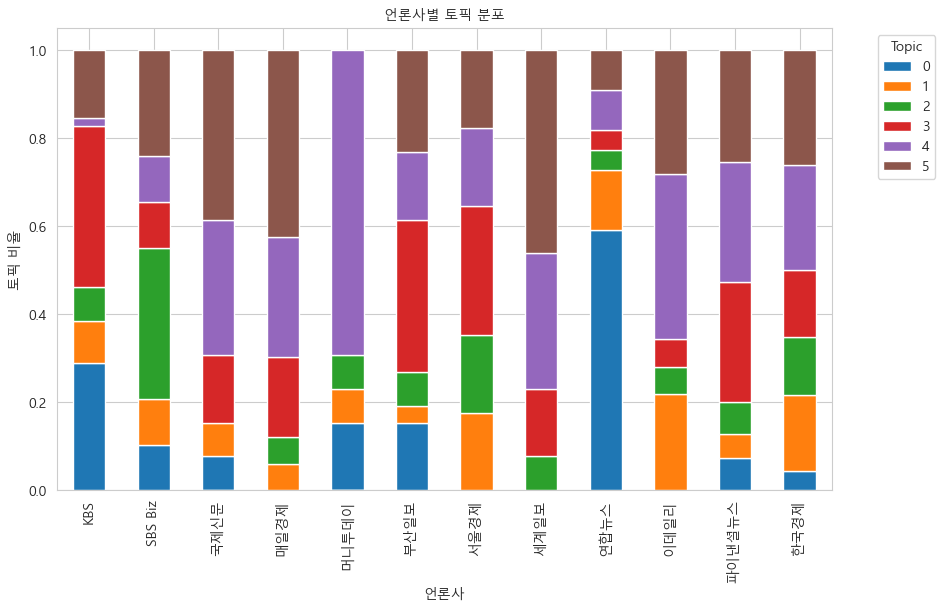

In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

topic_press_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("언론사별 토픽 분포", fontproperties=font_prop)
plt.xlabel("언론사", fontproperties=font_prop)
plt.ylabel("토픽 비율", fontproperties=font_prop)

plt.legend(title="Topic", bbox_to_anchor=(1.05,1))

plt.show()

#### 8️⃣ 토픽 키워드 표 생성

In [21]:
topic_keywords = {}

for i in range(6):
    words = lda_model.show_topic(i, topn=10)
    topic_keywords[i] = [w[0] for w in words]

topic_df = pd.DataFrame(topic_keywords).T
topic_df

,0,1,2,3,4,5,6,7,8,9
0,공항,안전,사고,항공,제주,공사,콘크리트,무안,설계,시설
1,미국,생산,전기,보조금,회장,공장,성장,현대차그룹,가격,최대
2,금융,센터,센터장,부장,기업,사업,팀장,전략,분양,은행
3,사업,혁신,위기,회장,경영,신년사,기업,기술,그룹,지역
4,기업,기술,로봇,금융,대표,서비스,개발,고객,사업,시장
5,경제,시장,전망,투자,성장,금리,정책,미국,확대,국내


#### 9️⃣ 결과 저장

In [22]:
# news_lda_result.csv: 각 뉴스 기사가 어떤 토픽에 할당됐는지 저장한 파일
# press_topic_ratio.csv: 언론사별 토픽 비율(토픽 분포)을 저장한 파일

In [23]:
df.to_csv("news_lda_result.csv", index=False)
topic_press_ratio.to_csv("press_topic_ratio.csv")